In [1]:
# the libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable





from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'



In [2]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds

def encode_time(ds, reference_time = '1958-01-01', period = 'months'):
    ds.time.encoding['calendar'] = '360_day'
    ds.time.encoding['units'] = '{} since {}'.format(period, reference_time)
    return ds


In [3]:
# load nino
fp = '/data/jmex/output/drivers/indices/nino.nc'
nino = decode_time(fp)
ninoOND = nino.where(nino.time.dt.month.isin([10,11,12])).groupby('time.year').mean()
ninoJAS = nino.where(nino.time.dt.month.isin([7,8,9])).groupby('time.year').mean()
ninoJFM = nino.where(nino.time.dt.month.isin([1,2,3])).groupby('time.year').mean()

# TAS

In [52]:
fp = '/data/jmex/ERA5/monthly/iera5_t2m_1991_2020_anom.info_0.00-359.75E_90.00--90.00N_n.nc'
t2m = decode_time(fp).sel(time = slice('1958',  '2024'))

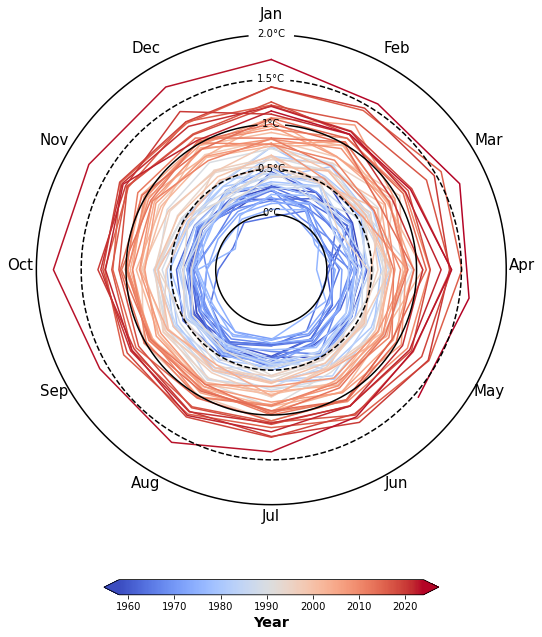

In [20]:



months=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

os = 1.5

full_circle_thetas=np.linspace(0+0.1,2*np.pi-0.1,1000)+np.pi/2
bl_0=[-0.88+os]*1000
bl_05=[0.5-.88+os]*1000
bl_1=[1-.88+os]*1000
bl_15=[1.5-0.88+os]*1000
bl_2=[2-0.88+os]*1000



# Extract years and months
years = np.unique(t2m.time.dt.year)

# Plotting
fig = plt.figure(figsize=(12,12))
ax = plt.subplot(111, projection='polar')#visuals
ax.axes.get_yaxis().set_ticklabels([])
ax.axes.get_xaxis().set_ticklabels([])
ax.set_axis_off()
ax.grid(False)

ax.plot(full_circle_thetas, bl_0, c='k', zorder= 10)
ax.plot(full_circle_thetas, bl_05, c='k', zorder= 10, linestyle = '--')
ax.plot(full_circle_thetas, bl_1, c='k', zorder= 10)
ax.plot(full_circle_thetas, bl_15, c='k', zorder= 10, linestyle = '--')
ax.plot(full_circle_thetas, bl_2, c='k', zorder= 10)




ax.text(np.pi/2, os-.90, s = "0°C", color="k", ha='center', zorder = 10)
ax.text(np.pi/2,os+0.5-.90, s = "0.5°C", color="k", ha='center', zorder = 10)
ax.text(np.pi/2,os+1-.90, s = "1°C", color="k", ha='center', zorder = 10)
ax.text(np.pi/2,os+1.5-.90, s = "1.5°C", color="k", ha='center', zorder = 10)
ax.text(np.pi/2,os+2.-.90, s = "2.0°C", color="k", ha='center', zorder = 10)



norm = mcolors.Normalize(vmin=min(years), vmax=max(years))
sm = ScalarMappable(norm=norm, cmap='rainbow')


#add months ring
months_angles= -np.linspace(0,2*np.pi,13)+np.pi/2
for i,month in enumerate(months):
    ax.text(months_angles[i],os+1.3,month,color="k",fontsize=15,ha="center")


for i, year in enumerate(years):
    temp = t2m.sel(time = slice(str(year), '{}-01'.format(year+1))).t2m.values

    # Calculate the angle for the current month
    angle = -np.linspace(0, 2*np.pi, len(temp))+np.pi/2

    # Calculate radius for temperature
    radius = temp +os
    cbar = ax.plot(angle, radius,  markersize=2, c=plt.cm.coolwarm(norm(year)))

# Create ScalarMappable object
sm = ScalarMappable(cmap=plt.cm.coolwarm, norm=norm)
sm.set_array([])  # Set empty array

# Create colorbar
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', label='Year',
                    extend = 'both', shrink = 0.5, pad = 0.1)

"""  
#year == 2023:

temp = t2m.sel(time = slice('2016', '2017-01')).t2m.values
angle = -np.linspace(0, 2*np.pi, len(temp))+np.pi/2
radius = temp+os
ax.plot(angle, radius, marker = 'o', markersize = 2, label = '2023', color = 'r', zorder = 20)
"""

# Set title and show the plot
#ax.set_title('GSAT Anomalies', color='k', fontdict={'fontsize': 20}, pad  = 30)
#ax.legend(loc = 'lower center')
plt.show()




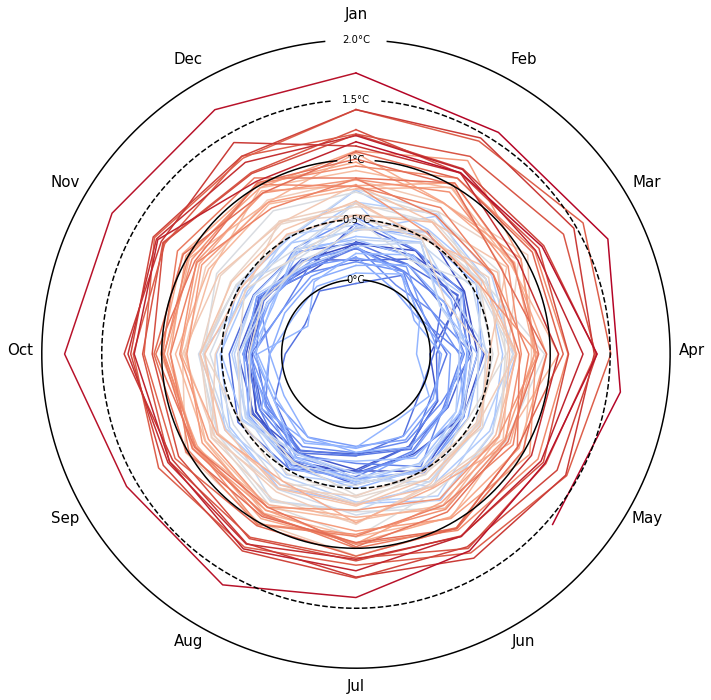

In [21]:
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.animation import FuncAnimation


months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
os = 1.5

full_circle_thetas = np.linspace(0 + 0.1, 2 * np.pi - 0.1, 1000) + np.pi / 2
bl_0 = [-0.88 + os] * 1000
bl_05 = [0.5 - 0.88 + os] * 1000
bl_1 = [1 - 0.88 + os] * 1000
bl_15 = [1.5 - 0.88 + os] * 1000
bl_2 = [2 - 0.88 + os] * 1000

years = np.unique(t2m.time.dt.year)

fig = plt.figure(figsize=(12, 12))
ax = plt.subplot(111, projection='polar')
ax.axes.get_yaxis().set_ticklabels([])
ax.axes.get_xaxis().set_ticklabels([])
ax.set_axis_off()
ax.grid(False)

ax.plot(full_circle_thetas, bl_0, c='k', zorder=10)
ax.plot(full_circle_thetas, bl_05, c='k', zorder=10, linestyle='--')
ax.plot(full_circle_thetas, bl_1, c='k', zorder=10)
ax.plot(full_circle_thetas, bl_15, c='k', zorder=10, linestyle='--')
ax.plot(full_circle_thetas, bl_2, c='k', zorder=10)

ax.text(np.pi/2, os-.90, s="0°C", color="k", ha='center', zorder=10)
ax.text(np.pi/2, os+0.5-.90, s="0.5°C", color="k", ha='center', zorder=10)
ax.text(np.pi/2, os+1-.90, s="1°C", color="k", ha='center', zorder=10)
ax.text(np.pi/2, os+1.5-.90, s="1.5°C", color="k", ha='center', zorder=10)
ax.text(np.pi/2, os+2.-.90, s="2.0°C", color="k", ha='center', zorder=10)

months_angles = -np.linspace(0, 2 * np.pi, 13) + np.pi / 2
for i, month in enumerate(months):
    ax.text(months_angles[i], os + 1.3, month, color="k", fontsize=15, ha="center")

norm = mcolors.Normalize(vmin=min(years), vmax=max(years))
sm = ScalarMappable(norm=norm, cmap='rainbow')

lines = []

# Create initial empty lines for each year
for _ in years:
    line, = ax.plot([], [], markersize=2)
    lines.append(line)

def update(frame):
    year = years[frame]
    temp = t2m.sel(time=slice(str(year), '{}-01'.format(year+1))).t2m.values

    # Calculate the angle for the current month
    angle = -np.linspace(0, 2 * np.pi, len(temp)) + np.pi / 2

    # Calculate radius for temperature
    radius = temp + os
    lines[frame].set_data(angle, radius)
    lines[frame].set_color(plt.cm.coolwarm(norm(year)))

    return lines

ani = FuncAnimation(fig, update, frames=len(years), blit=True, repeat=False)

# Save the animation
ani.save('/data/jmex/output/anim/temperature_animation.gif', writer='imagemagick', fps=1)

plt.show()


0
0
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
27

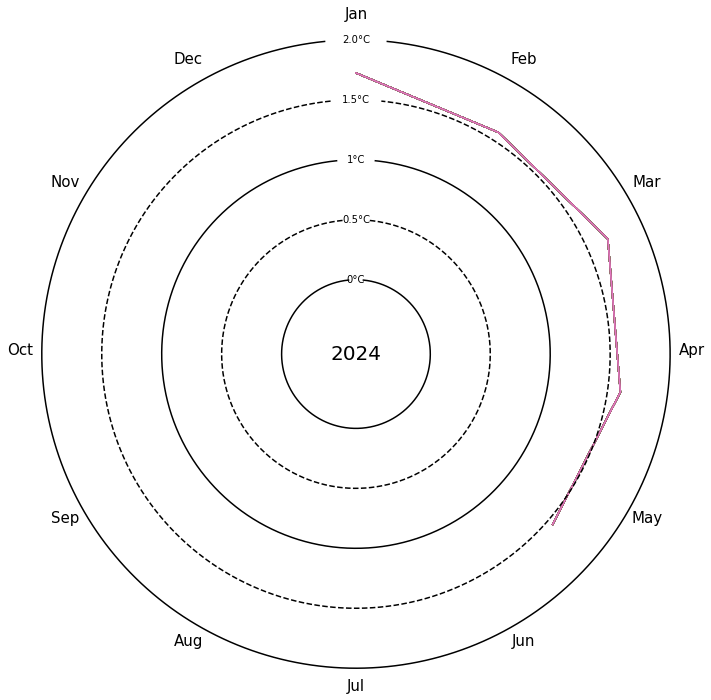

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.animation import FuncAnimation, FFMpegWriter

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
os = 1.5

full_circle_thetas = np.linspace(0 + 0.1, 2 * np.pi - 0.1, 1000) + np.pi / 2
bl_0 = [-0.88 + os] * 1000
bl_05 = [0.5 - 0.88 + os] * 1000
bl_1 = [1 - 0.88 + os] * 1000
bl_15 = [1.5 - 0.88 + os] * 1000
bl_2 = [2 - 0.88 + os] * 1000

years = np.unique(t2m.time.dt.year)

fig = plt.figure(figsize=(12, 12))
ax = plt.subplot(111, projection='polar')
ax.axes.get_yaxis().set_ticklabels([])
ax.axes.get_xaxis().set_ticklabels([])
ax.set_axis_off()
ax.grid(False)

ax.plot(full_circle_thetas, bl_0, c='k', zorder=10)
ax.plot(full_circle_thetas, bl_05, c='k', zorder=10, linestyle='--')
ax.plot(full_circle_thetas, bl_1, c='k', zorder=10)
ax.plot(full_circle_thetas, bl_15, c='k', zorder=10, linestyle='--')
ax.plot(full_circle_thetas, bl_2, c='k', zorder=10)

ax.text(np.pi/2, os-.90, s="0°C", color="k", ha='center', zorder=10)
ax.text(np.pi/2, os+0.5-.90, s="0.5°C", color="k", ha='center', zorder=10)
ax.text(np.pi/2, os+1-.90, s="1°C", color="k", ha='center', zorder=10)
ax.text(np.pi/2, os+1.5-.90, s="1.5°C", color="k", ha='center', zorder=10)
ax.text(np.pi/2, os+2.-.90, s="2.0°C", color="k", ha='center', zorder=10)

months_angles = -np.linspace(0, 2 * np.pi, 13) + np.pi / 2
for i, month in enumerate(months):
    ax.text(months_angles[i], os + 1.3, month, color="k", fontsize=15, ha="center")

norm = mcolors.Normalize(vmin=min(years), vmax=max(years))
sm = ScalarMappable(norm=norm, cmap='rainbow')

lines = []
points = []

# Create initial empty lines for each year
for _ in years:
    line, = ax.plot([], [], markersize=2)
    point, = ax.plot([], [], 'o', color='red')  # Points for last data point
    lines.append(line)
    points.append(point)

year_text = ax.text(0, 0, '', ha='center', va='center', fontsize=20, color='black')

def update(frame):
    print(frame)
    year_idx = frame // 12
    month_idx = frame % 12
    year = years[year_idx]

    temp = t2m.sel(time=slice(str(year), '{}-01'.format(year + 1))).t2m.values
    angle = -np.linspace(0, 2 * np.pi, len(temp)) + np.pi / 2
    radius = temp + os

    for i in range(year_idx + 1):
        end = 12 if i < year_idx else month_idx + 1
        lines[i].set_data(angle[:end], radius[:end])
        if i == year_idx:
            points[i].set_data(angle[month_idx], radius[month_idx])
        else:
            points[i].set_data([], [])

    year_text.set_text(str(year))

    return lines + points + [year_text]

ani = FuncAnimation(fig, update, frames=len(years) * 12, blit=True, repeat=False)

# Save the animation as a video file
writer = FFMpegWriter(fps=12, metadata=dict(artist='Me'), bitrate=1800)
ani.save('temperature_animation.mp4', writer=writer)

plt.show()


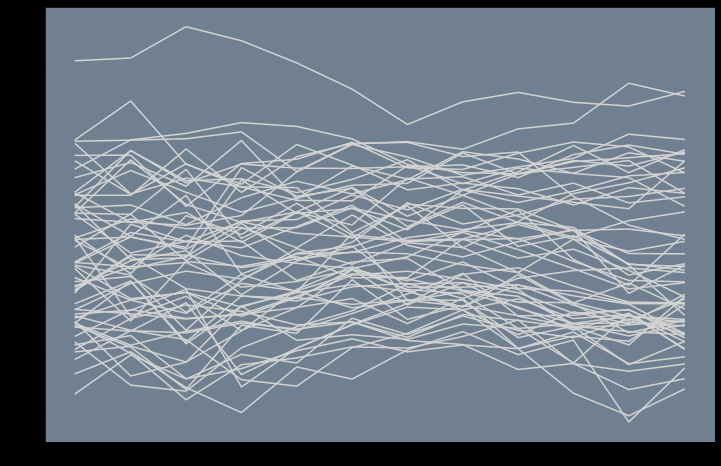

In [44]:

# Create a new figure with a light blue background color
fig = plt.figure(facecolor='k', figsize = (12,8))

# Add a subplot with a specific background color for the axes
ax = fig.add_subplot(111, facecolor='slategrey')

for year in np.unique(t2m.sel(time = slice(None, '2016')).time.dt.year):
    ax.plot(t2m.sel(time = str(year)).t2m.values, c = 'lightgrey')

In [46]:
t = t2m.t2m.data
m = t2m.time.dt.month

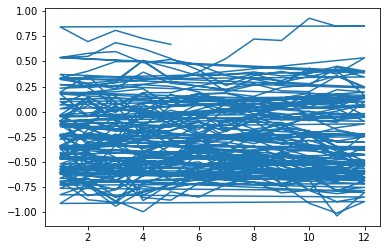

In [48]:
plt.plot(m,t)

# T500

In [4]:
fp = '/data/jmex/ERA5/monthly/iera5_t500_0.00-359.75E_20--20N_n_a.txt.nc'

t500 = decode_time(fp)

In [5]:



def detrend_monthly(group):
    ns_century = 1.e9*3600.*24.*365.*100.
    linfit = group.polyfit('time', 1)
    slope = linfit.polyfit_coefficients.isel(degree=0) * ns_century

    trend = xr.polyval(coord=group.time, coeffs=linfit.polyfit_coefficients)
    detrended_group = group - trend.values + group.mean(dim='time')

    return detrended_group


dtr = t500.t.groupby('time.month').apply(detrend_monthly)


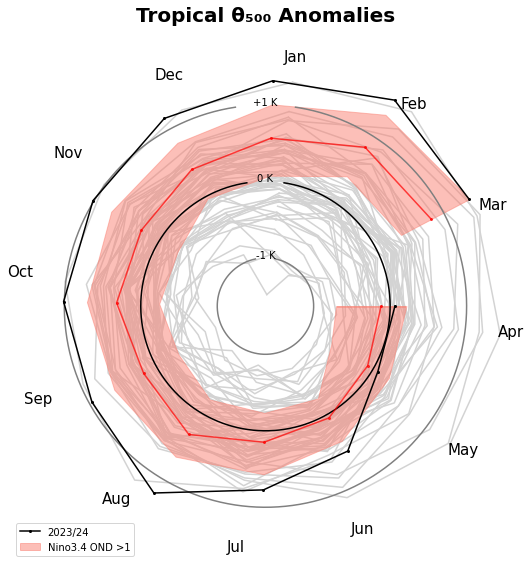

In [7]:

months=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

full_circle_thetas=np.linspace(0+0.15,2*np.pi-0.15,1000)+np.pi/2


m=np.zeros(1000)

#set offset
os = 1

# Extract years and months
years = np.unique(t500.t.time.dt.year)

# Plotting
fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, projection='polar')#visuals
ax.axes.get_yaxis().set_ticklabels([])
ax.axes.get_xaxis().set_ticklabels([])
ax.set_axis_off()
ax.grid(False)


#circle for mean
ax.plot(full_circle_thetas, m+os, c='k', zorder= 10)
#ax.errorbar(np.linspace(0,24/13*np.pi, 12), np.zeros(12)+os, yerr=std,
 #           linestyle = ' ', c='k', zorder= 10)

ax.text(np.pi/2, os, "0 K", color="k", ha='center', zorder = 10)


#circle for +1K
ax.plot(full_circle_thetas, m+os+1, c='grey', zorder= 10)
#ax.errorbar(np.linspace(0,24/13*np.pi, 12), np.zeros(12)+os, yerr=std,
 #           linestyle = ' ', c='k', zorder= 10)

ax.text(np.pi/2, 1+os, "+1 K", color="k", ha='center', zorder = 10)

#circle for +1K
ax.plot(full_circle_thetas[10:990], m[10:990]+os-1, c='grey', zorder= 10)
#ax.errorbar(np.linspace(0,24/13*np.pi, 12), np.zeros(12)+os, yerr=std,
 #           linestyle = ' ', c='k', zorder= 10)

ax.text(np.pi/2, -1.+os, "-1 K", color="k", ha='center', zorder = 10)




#add months ring
months_angles= -np.linspace(0,2*np.pi,13)+2*np.pi*3/13
for i,month in enumerate(months):
    ax.text(months_angles[i],os+1.6,month,color="k",fontsize=15,ha="center")


for i, year in enumerate(years[11:]):
    temp = t500.t.sel(time = slice(str(year), '{}-01'.format(year+1))).values

    # Calculate the angle for the current month
    angle = -np.linspace(0, 2*np.pi, len(temp))+2*np.pi*3/13

    # Calculate radius for temperature
    radius = temp +os
    ax.plot(angle, radius,  markersize=2, c='lightgrey')

    
#year == 2023:
temp = t500.t.sel(time = slice('2023-04', '2024-03')).values
angle = -np.linspace(3/13*np.pi*2,15/13*2*np.pi, len(temp))+2*np.pi*3/13
radius = temp+os
ax.plot(angle, radius, marker = 'o', markersize = 2, label = '2023/24', color = 'k', zorder = 20)



nino_years = ninoOND.year[ninoOND.nino34>1].values
t500_nino = xr.concat([t500.t.sel(time = slice('{}-04'.format(y), '{}-03'.format(y+1))) for y in nino_years], dim = 'time')    
    

#add nino
if True:
    #nino
    nino_years = ninoOND.year[ninoOND.nino34>1].values
    t500_nino = xr.concat([t500.t.sel(time = slice('{}-04'.format(y), '{}-03'.format(y+1))) for y in nino_years], dim = 'time')    
    temp_m = t500_nino.groupby('time.month').mean().roll(month = -3)
    temp_10 = t500_nino.groupby('time.month').quantile(.10).roll(month = -3)
    temp_90 = t500_nino.groupby('time.month').quantile(0.9).roll(month = -3)

    angle = -np.linspace(3/13*np.pi*2,15/13*2*np.pi, len(temp_m))+2*np.pi*3/13
    radius_m = temp_m+os
    ax.plot(angle, radius_m, marker = 'o', markersize = 2, color = 'red', zorder = 10, alpha = 0.7)
    ax.fill_between(angle, temp_10+os, temp_90+os, color = 'salmon', label = 'Nino3.4 OND >1', zorder= 10, alpha = 0.5)



# Set title and show the plot
ax.set_title('Tropical θ₅₀₀ Anomalies', color='k', fontdict={'fontsize': 20}, pad  = 30)
ax.legend(loc = 'lower left')
plt.tight_layout()
plt.show()




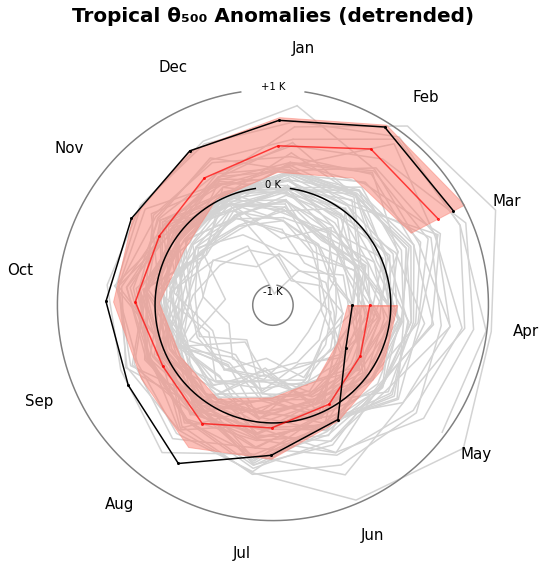

In [8]:

months=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

full_circle_thetas=np.linspace(0+0.15,2*np.pi-0.15,1000)+np.pi/2


m=np.zeros(1000)

#set offset
os = 1

# Extract years and months
years = np.unique(dtr.time.dt.year)

# Plotting
fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, projection='polar')#visuals
ax.axes.get_yaxis().set_ticklabels([])
ax.axes.get_xaxis().set_ticklabels([])
ax.set_axis_off()
ax.grid(False)


#circle for mean
ax.plot(full_circle_thetas, m+os, c='k', zorder= 10)
#ax.errorbar(np.linspace(0,24/13*np.pi, 12), np.zeros(12)+os, yerr=std,
 #           linestyle = ' ', c='k', zorder= 10)

ax.text(np.pi/2, os, "0 K", color="k", ha='center', zorder = 10)


#circle for +1K
ax.plot(full_circle_thetas, m+os+1, c='grey', zorder= 10)
#ax.errorbar(np.linspace(0,24/13*np.pi, 12), np.zeros(12)+os, yerr=std,
 #           linestyle = ' ', c='k', zorder= 10)

ax.text(np.pi/2, 1+os, "+1 K", color="k", ha='center', zorder = 10)

#circle for +1K
ax.plot(full_circle_thetas[10:990], m[10:990]+os-1, c='grey', zorder= 10)
#ax.errorbar(np.linspace(0,24/13*np.pi, 12), np.zeros(12)+os, yerr=std,
 #           linestyle = ' ', c='k', zorder= 10)

ax.text(np.pi/2, -1.1+os, "-1 K", color="k", ha='center', zorder = 10)




#add months ring
months_angles= -np.linspace(0,2*np.pi,13)+2*np.pi*3/13
for i,month in enumerate(months):
    ax.text(months_angles[i],os+1.4,month,color="k",fontsize=15,ha="center")


for i, year in enumerate(years[11:]):
    temp = dtr.sel(time = slice(str(year), '{}-01'.format(year+1))).values

    # Calculate the angle for the current month
    angle = -np.linspace(0, 2*np.pi, len(temp))+2*np.pi*3/13

    # Calculate radius for temperature
    radius = temp +os
    ax.plot(angle, radius,  markersize=2, c='lightgrey')

    
#year == 2023:
temp = dtr.sel(time = slice('2023-04', '2024-03')).values
angle = -np.linspace(3/13*np.pi*2,15/13*2*np.pi, len(temp))+2*np.pi*3/13
radius = temp+os
ax.plot(angle, radius, marker = 'o', markersize = 2, label = '2023/24', color = 'k', zorder = 20)



nino_years = ninoOND.year[ninoOND.nino34>1].values
dtr_nino = xr.concat([dtr.sel(time = slice('{}-04'.format(y), '{}-03'.format(y+1))) for y in nino_years], dim = 'time')    
    

#add nino
if True:
    #nino
    nino_years = ninoOND.year[ninoOND.nino34>1].values
    dtr_nino = xr.concat([dtr.sel(time = slice('{}-04'.format(y), '{}-03'.format(y+1))) for y in nino_years], dim = 'time')    
    temp_m = dtr_nino.groupby('time.month').mean().roll(month = -3)
    temp_10 = dtr_nino.groupby('time.month').quantile(.10).roll(month = -3)
    temp_90 = dtr_nino.groupby('time.month').quantile(0.9).roll(month = -3)

    angle = -np.linspace(3/13*np.pi*2,15/13*2*np.pi, len(temp_m))+2*np.pi*3/13
    radius_m = temp_m+os
    ax.plot(angle, radius_m, marker = 'o', markersize = 2, color = 'red', zorder = 10, alpha = 0.7)
    ax.fill_between(angle, temp_10+os, temp_90+os, color = 'salmon', label = 'Nino3.4 OND >1', zorder= 10, alpha = 0.5)



# Set title and show the plot
ax.set_title('Tropical θ₅₀₀ Anomalies (detrended)', color='k', fontdict={'fontsize': 20}, pad  = 30)
#ax.legend(loc = 'upper left')
plt.tight_layout()
plt.show()




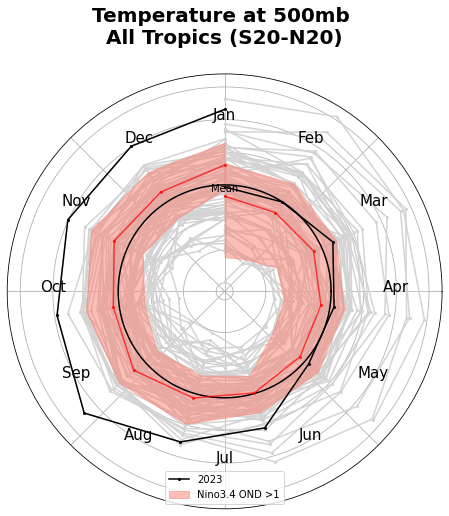

In [9]:

months=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

std = dtr.groupby('time.month').std()

full_circle_thetas=np.linspace(0,2*np.pi,1000)
m=np.zeros(1000)

#set offset
os = 1

# Extract years and months
years = np.unique(t500.time.dt.year)

# Plotting
fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, projection='polar')#visuals
ax.axes.get_yaxis().set_ticklabels([])
ax.axes.get_xaxis().set_ticklabels([])

ax.plot(full_circle_thetas, m+os, c='k', zorder= 10)

ax.text(np.pi/2, .90, "Mean", color="k", ha='center', zorder = 10)

#add months ring
months_angles= -np.linspace(0,2*np.pi,13)+np.pi/2
for i,month in enumerate(months):
    ax.text(months_angles[i],2,month,color="k",fontsize=15,ha="center")


for i, year in enumerate(years):
    temp = t500.where((t500.time.dt.year== year), drop = True).t.values

    # Calculate the angle for the current month
    angle = -np.linspace(0, 2*np.pi, len(temp))+np.pi/2

    # Calculate radius for temperature
    radius = temp +1
    ax.plot(angle, radius, marker='o', markersize=2, c='lightgrey')
    

add_nino = True
add_nino_all = False
add_nino2 = False

add_nina = False
    
#year == 2023:

temp = t500.sel(time = '2023').t.values
angle = -np.linspace(0,2*np.pi, len(temp))+np.pi/2
radius = temp+1
ax.plot(angle, radius, marker = 'o', markersize = 2, label = '2023', color = 'k', zorder = 20)

"""
#year == 2009:

temp = t500.sel(time = '2009').t.values
angle = -np.linspace(0,2*np.pi, len(temp))+np.pi/2
radius = temp+1
ax.plot(angle, radius, marker = 'o', markersize = 2, label = '2009', color = 'g', zorder = 20)
"""


if add_nino:
    #nino
    nino_W = t500.sel(time = t500.time.dt.year.isin(ninoOND.where(ninoOND.nino34>1., drop = True).year[:-1]))
    temp_m = nino_W.groupby('time.month').mean().t.values
    temp_10 = nino_W.t.groupby('time.month').quantile(.10)
    temp_90 = nino_W.t.groupby('time.month').quantile(0.9)

    angle = -np.linspace(0,2*np.pi, len(temp_m))+np.pi/2
    radius_m = temp_m+1
    ax.plot(angle, radius_m, marker = 'o', markersize = 2, color = 'red', zorder = 10, alpha = 0.7)
    ax.fill_between(angle, temp_10+1, temp_90+1, color = 'salmon', label = 'Nino3.4 OND >1', zorder= 10, alpha = 0.5)


#Set title and show the plot
ax.set_title('Temperature at 500mb \nAll Tropics (S20-N20)', color='k', fontdict={'fontsize': 20}, pad  = 30)
ax.legend(loc = 'lower center')



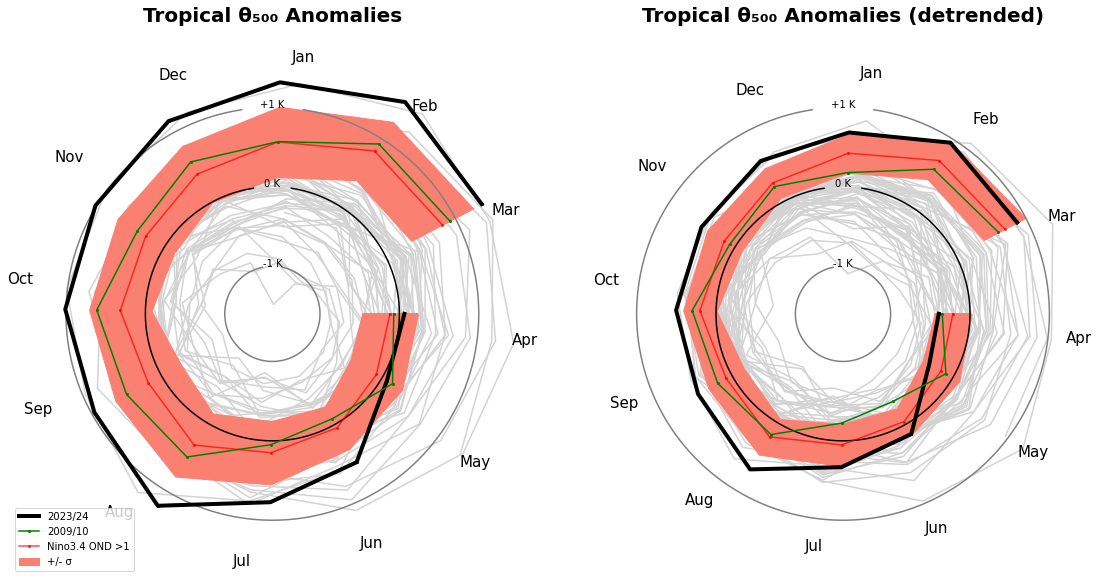

In [12]:
create a linkimport matplotlib.pyplot as plt
import numpy as np
import xarray as xr

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
full_circle_thetas = np.linspace(0+0.15, 2*np.pi-0.15, 1000) + np.pi/2
m = np.zeros(1000)
os = 1

# Assuming t500 and dtr are defined xarray DataArrays with time dimension
# and ninoOND is a DataFrame or xarray with nino3.4 index/column

# Extract years and months
years = np.unique(t500.t.time.dt.year)

# Create the subplots
fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw=dict(projection='polar'), figsize=(16, 8))

# Plot for the first dataset
ax1.axes.get_yaxis().set_ticklabels([])
ax1.axes.get_xaxis().set_ticklabels([])
ax1.set_axis_off()
ax1.grid(False)

ax1.plot(full_circle_thetas, m + os, c='k', zorder=10)
ax1.text(np.pi/2, os, "0 K", color="k", ha='center', zorder=10)
ax1.plot(full_circle_thetas, m + os + 1, c='grey', zorder=10)
ax1.text(np.pi/2, 1 + os, "+1 K", color="k", ha='center', zorder=10)
ax1.plot(full_circle_thetas[10:990], m[10:990] + os - 1, c='grey', zorder=10)
ax1.text(np.pi/2, -1.0 + os, "-1 K", color="k", ha='center', zorder=10)

months_angles = -np.linspace(0, 2*np.pi, 13) + 2*np.pi * 3 / 13
for i, month in enumerate(months):
    ax1.text(months_angles[i], os + 1.6, month, color="k", fontsize=15, ha="center")

for i, year in enumerate(years[11:]):
    temp = t500.t.sel(time=slice(str(year), '{}-01'.format(year + 1))).values
    angle = -np.linspace(0, 2*np.pi, len(temp)) + 2*np.pi * 3 / 13
    radius = temp + os
    ax1.plot(angle, radius, markersize=2, c='lightgrey')

temp = t500.t.sel(time=slice('2023-04', '2024-03')).values
angle = -np.linspace(3 / 13 * np.pi * 2, 15 / 13 * 2 * np.pi, len(temp)) + 2 * np.pi * 3 / 13
radius = temp + os
ax1.plot(angle, radius, marker='o', markersize=2, label='2023/24', color='k', zorder=20, linewidth = 4)

#plot 2009
temp = t500.t.sel(time=slice('2009-04', '2010-03')).values
angle = -np.linspace(3 / 13 * np.pi * 2, 15 / 13 * 2 * np.pi, len(temp)) + 2 * np.pi * 3 / 13
radius = temp + os
ax1.plot(angle, radius, marker='o', markersize=2, label='2009/10', color='g', zorder=20)

nino_years = ninoOND.year[ninoOND.nino34 > 1].values
t500_nino = xr.concat([t500.t.sel(time=slice('{}-04'.format(y), '{}-03'.format(y + 1))) for y in nino_years], dim='time')
temp_m = t500_nino.groupby('time.month').mean().roll(month=-3)
temp_10 = t500_nino.groupby('time.month').quantile(.10).roll(month=-3)
temp_90 = t500_nino.groupby('time.month').quantile(0.9).roll(month=-3)
temp_std = t500_nino.groupby('time.month').std().roll(month=-3)



angle = -np.linspace(3 / 13 * np.pi * 2, 15 / 13 * 2 * np.pi, len(temp_m)) + 2 * np.pi * 3 / 13
radius_m = temp_m + os
ax1.plot(angle, radius_m, marker='o', markersize=2, color='red', zorder=10, alpha=0.7, label = 'Nino3.4 OND >1')
#ax1.fill_between(angle, temp_10 + os, temp_90 + os, color='salmon', label='Nino3.4 OND >1', zorder=10, alpha=1)

ax1.fill_between(angle, temp_m-temp_std + os, temp_m+temp_std + os, color='salmon', label='+/- σ', zorder=10, alpha=1)


ax1.set_title('Tropical θ₅₀₀ Anomalies', color='k', fontdict={'fontsize': 20}, pad=30)
ax1.legend(loc='lower left')

# Plot for the second dataset
ax2.axes.get_yaxis().set_ticklabels([])
ax2.axes.get_xaxis().set_ticklabels([])
ax2.set_axis_off()
ax2.grid(False)

ax2.plot(full_circle_thetas, m + os, c='k', zorder=10)
ax2.text(np.pi/2, os, "0 K", color="k", ha='center', zorder=10)
ax2.plot(full_circle_thetas, m + os + 1, c='grey', zorder=10)
ax2.text(np.pi/2, 1 + os, "+1 K", color="k", ha='center', zorder=10)
ax2.plot(full_circle_thetas[10:990], m[10:990] + os - 1, c='grey', zorder=10)
ax2.text(np.pi/2, -1.0 + os, "-1 K", color="k", ha='center', zorder=10)

for i, month in enumerate(months):
    ax2.text(months_angles[i], os + 1.4, month, color="k", fontsize=15, ha="center")

years = np.unique(dtr.time.dt.year)
for i, year in enumerate(years[11:]):
    temp = dtr.sel(time=slice(str(year), '{}-01'.format(year + 1))).values
    angle = -np.linspace(0, 2 * np.pi, len(temp)) + 2 * np.pi * 3 / 13
    radius = temp + os
    ax2.plot(angle, radius, markersize=2, c='lightgrey')

temp = dtr.sel(time=slice('2023-04', '2024-03')).values
angle = -np.linspace(3 / 13 * np.pi * 2, 15 / 13 * 2 * np.pi, len(temp)) + 2 * np.pi * 3 / 13
radius = temp + os
ax2.plot(angle, radius, marker='o', markersize=2, label='2023/24', color='k', zorder=20, linewidth = 4)
#plot 2009
temp = dtr.sel(time=slice('2009-04', '2010-03')).values
angle = -np.linspace(3 / 13 * np.pi * 2, 15 / 13 * 2 * np.pi, len(temp)) + 2 * np.pi * 3 / 13
radius = temp + os
ax2.plot(angle, radius, marker='o', markersize=2, label='2009/10', color='g', zorder=20)


dtr_nino = xr.concat([dtr.sel(time=slice('{}-04'.format(y), '{}-03'.format(y + 1))) for y in nino_years], dim='time')
temp_m = dtr_nino.groupby('time.month').mean().roll(month=-3)
#temp_10 = dtr_nino.groupby('time.month').quantile(.10).roll(month=-3)
#temp_90 = dtr_nino.groupby('time.month').quantile(0.9).roll(month=-3)
temp_std = dtr_nino.groupby('time.month').std().roll(month=-3)


angle = -np.linspace(3 / 13 * np.pi * 2, 15 / 13 * 2 * np.pi, len(temp_m)) + 2 * np.pi * 3 / 13
radius_m = temp_m + os
ax2.plot(angle, radius_m, marker='o', markersize=2, color='red', zorder=10, alpha=0.7)
#ax2.fill_between(angle, temp_10 + os, temp_90 + os, color='salmon', label='Nino3.4 OND >1', zorder=10, alpha=1)
ax2.fill_between(angle, temp_m-temp_std + os, temp_m+temp_std + os, color='salmon', label='Nino3.4 OND >1', zorder=10, alpha=1)

ax2.set_title('Tropical θ₅₀₀ Anomalies (detrended)', color='k', fontdict={'fontsize': 20}, pad=30)

ax1.set_ylim(-0.6, 2.7)
ax2.set_ylim(-0.6, 2.7)

plt.tight_layout()
plt.show()


# TP

In [12]:
#load dataset
fp = '/data/jmex/ERA5/daily/era5_tp_daily_120-280E_-20-20N.nc'
tp = xr.open_dataset(fp).sel(lon = slice(130,150))

#select rev. time only
tp = tp.sel(time = slice('1958-01-01', '2023-12-31'))

In [13]:
#compute the mean
tp_weights = np.cos(np.deg2rad(tp.lat))
tp_glbmean = tp.weighted(tp_weights).mean(['lat', 'lon'])



#compute the anomaly
tp_glbanom = tp_glbmean.groupby('time.dayofyear')-tp_glbmean.groupby('time.dayofyear').mean() 

tp['glb_mean'] = tp_glbmean.rolling(time = 90).mean('time', center = True).tp
tp['glb_anom'] = tp_glbanom.rolling(time = 90).mean('time', center = True).tp

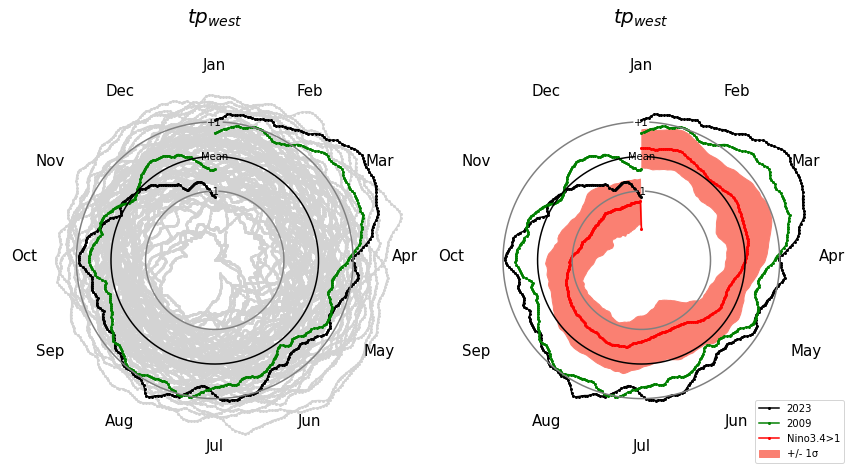

In [14]:
os = 1
# Assuming tp and ninoOND are already loaded as xarray datasets

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
full_circle_thetas = np.linspace(0, 2 * np.pi, 1000)+np.pi/2
mean_radii = np.zeros(1000)+os

# Extract years
years = np.unique(tp.time.dt.year)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 8), subplot_kw={'projection': 'polar'})
add_all = True
add_nino = True

for ax in axes:
    ax.axes.get_yaxis().set_ticklabels([])
    ax.axes.get_xaxis().set_ticklabels([])
    ax.grid(False)
    ax.set_axis_off()

    ax.set_ylim(-2,4)
    
    ax.plot(full_circle_thetas[10:990], mean_radii[10:990]+1, c='grey', zorder=10)
    ax.text(np.pi / 2, 0.90, "Mean", color="k", ha='center', zorder=10)
    #+1
    ax.plot(full_circle_thetas[10:990], mean_radii[10:990], c='k', zorder=10)
    ax.text(np.pi / 2, 1.90, "+1", color="k", ha='center', zorder=10)
    #-1
    ax.plot(full_circle_thetas[10:990], mean_radii[10:990]-1, c='grey', zorder=10)
    ax.text(np.pi / 2, -1+0.90, "-1", color="k", ha='center', zorder=10)

    months_angles = -np.linspace(0, 2 * np.pi, 13) + np.pi / 2
    for i, month in enumerate(months):
        ax.text(months_angles[i], 3.5, month, color="k", fontsize=15, ha="center")

for i, year in enumerate(years):
    temp = tp.where((tp.time.dt.year == year), drop=True).glb_anom.values
    angle = -np.linspace(0, 2 * np.pi, len(temp)) + np.pi / 2
    radius = temp + 1

    if add_all:
        axes[0].plot(angle, radius, marker='o', markersize=2, c='lightgrey')

# Plot specific years
specific_years = {'2023': 'k', '2009':'g'}
for year, color in specific_years.items():
    temp = tp.sel(time=year).glb_anom.values
    angle = -np.linspace(0, 2 * np.pi, len(temp)) + np.pi / 2
    radius = temp + 1
    for ax in axes:
        ax.plot(angle, radius, marker='o', markersize=2, label=year, color=color)

if add_nino:
    nino_tp = tp.sel(time=tp.time.dt.year.isin(ninoOND.where(ninoOND.nino34 > 1, drop=True).year[:-1]))
    temp_m = nino_tp.groupby('time.dayofyear').mean().glb_anom.values
#    temp_10 = nino_tp.glb_anom.groupby('time.dayofyear').quantile(.10)
#    temp_90 = nino_tp.glb_anom.groupby('time.dayofyear').quantile(.90)

    temp_std = nino_tp.groupby('time.dayofyear').std().glb_anom.values
    
    angle = -np.linspace(0, 2 * np.pi, len(temp_m)) + np.pi / 2
    radius_m = temp_m + 1

    axes[1].plot(angle, radius_m, marker='o', markersize=2, color='red', label = 'Nino3.4>1')
    axes[1].fill_between(angle, temp_m-temp_std + os, temp_m+temp_std + os, color='salmon', label='+/- 1σ')


    

# Set titles
axes[0].set_title(r"$tp_{west}$", color='k', fontdict={'fontsize': 20, 'fontweight':'bold'}, pad=30)
axes[1].set_title(r"$tp_{west}$", color='k', fontdict={'fontsize': 20, 'fontweight':'bold'}, pad=30)

plt.rc('text', usetex=False)
# Add legends
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()


In [19]:
#load dataset
fp = '/data/jmex/ERA5/daily/era5_tp_daily_110-150E_20--20N_1950-2024.nc'
tp = xr.open_dataset(fp).sel(lon = slice(130,150))

#select rev. time only
tp = tp.sel(time = slice('1958-01-01', '2023-12-31'))

In [20]:
#compute the mean
tp_weights = np.cos(np.deg2rad(tp.lat))
tp_glbmean = tp.weighted(tp_weights).mean(['lat', 'lon'])



#compute the anomaly
tp_glbanom = tp_glbmean.groupby('time.dayofyear')-tp_glbmean.groupby('time.dayofyear').mean() 

tp['glb_mean'] = tp_glbmean.rolling(time = 90).mean('time', center = True).tp
tp['glb_anom'] = tp_glbanom.rolling(time = 90).mean('time', center = True).tp

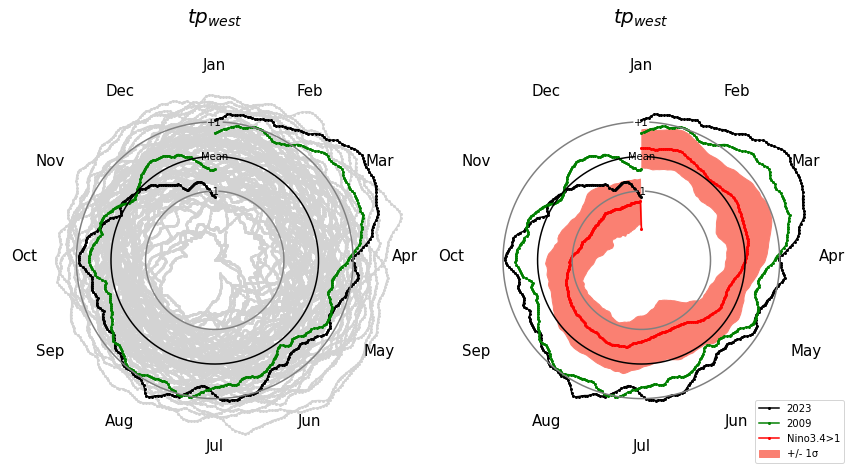

In [21]:
os = 1
# Assuming tp and ninoOND are already loaded as xarray datasets

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
full_circle_thetas = np.linspace(0, 2 * np.pi, 1000)+np.pi/2
mean_radii = np.zeros(1000)+os

# Extract years
years = np.unique(tp.time.dt.year)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 8), subplot_kw={'projection': 'polar'})
add_all = True
add_nino = True

for ax in axes:
    ax.axes.get_yaxis().set_ticklabels([])
    ax.axes.get_xaxis().set_ticklabels([])
    ax.grid(False)
    ax.set_axis_off()

    ax.set_ylim(-2,4)
    
    ax.plot(full_circle_thetas[10:990], mean_radii[10:990]+1, c='grey', zorder=10)
    ax.text(np.pi / 2, 0.90, "Mean", color="k", ha='center', zorder=10)
    #+1
    ax.plot(full_circle_thetas[10:990], mean_radii[10:990], c='k', zorder=10)
    ax.text(np.pi / 2, 1.90, "+1", color="k", ha='center', zorder=10)
    #-1
    ax.plot(full_circle_thetas[10:990], mean_radii[10:990]-1, c='grey', zorder=10)
    ax.text(np.pi / 2, -1+0.90, "-1", color="k", ha='center', zorder=10)

    months_angles = -np.linspace(0, 2 * np.pi, 13) + np.pi / 2
    for i, month in enumerate(months):
        ax.text(months_angles[i], 3.5, month, color="k", fontsize=15, ha="center")

for i, year in enumerate(years):
    temp = tp.where((tp.time.dt.year == year), drop=True).glb_anom.values
    angle = -np.linspace(0, 2 * np.pi, len(temp)) + np.pi / 2
    radius = temp + 1

    if add_all:
        axes[0].plot(angle, radius, marker='o', markersize=2, c='lightgrey')

# Plot specific years
specific_years = {'2023': 'k', '2009':'g'}
for year, color in specific_years.items():
    temp = tp.sel(time=year).glb_anom.values
    angle = -np.linspace(0, 2 * np.pi, len(temp)) + np.pi / 2
    radius = temp + 1
    for ax in axes:
        ax.plot(angle, radius, marker='o', markersize=2, label=year, color=color)

if add_nino:
    nino_tp = tp.sel(time=tp.time.dt.year.isin(ninoOND.where(ninoOND.nino34 > 1, drop=True).year[:-1]))
    temp_m = nino_tp.groupby('time.dayofyear').mean().glb_anom.values
#    temp_10 = nino_tp.glb_anom.groupby('time.dayofyear').quantile(.10)
#    temp_90 = nino_tp.glb_anom.groupby('time.dayofyear').quantile(.90)

    temp_std = nino_tp.groupby('time.dayofyear').std().glb_anom.values
    
    angle = -np.linspace(0, 2 * np.pi, len(temp_m)) + np.pi / 2
    radius_m = temp_m + 1

    axes[1].plot(angle, radius_m, marker='o', markersize=2, color='red', label = 'Nino3.4>1')
    axes[1].fill_between(angle, temp_m-temp_std + os, temp_m+temp_std + os, color='salmon', label='+/- 1σ')


    

# Set titles
axes[0].set_title(r"$tp_{west}$", color='k', fontdict={'fontsize': 20, 'fontweight':'bold'}, pad=30)
axes[1].set_title(r"$tp_{west}$", color='k', fontdict={'fontsize': 20, 'fontweight':'bold'}, pad=30)

plt.rc('text', usetex=False)
# Add legends
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()


# TP with larger boxes

extend the selection zonally to be 110-150, sam area as the ascending branch in the Hadley circ index


In [16]:
#load dataset
fp = '/data/jmex/ERA5/daily/era5_tp_daily_110-150E_20--20N_1950-2024.nc'
tp = xr.open_dataset(fp).sel(lon = slice(110,150))

#select rev. time only
tp = tp.sel(time = slice('1958-01-01', '2023-12-31'))

In [17]:
#compute the mean
tp_weights = np.cos(np.deg2rad(tp.lat))
tp_glbmean = tp.weighted(tp_weights).mean(['lat', 'lon'])



#compute the anomaly
tp_glbanom = tp_glbmean.groupby('time.dayofyear')-tp_glbmean.groupby('time.dayofyear').mean() 

tp['glb_mean'] = tp_glbmean.rolling(time = 90).mean('time', center = True).tp
tp['glb_anom'] = tp_glbanom.rolling(time = 90).mean('time', center = True).tp

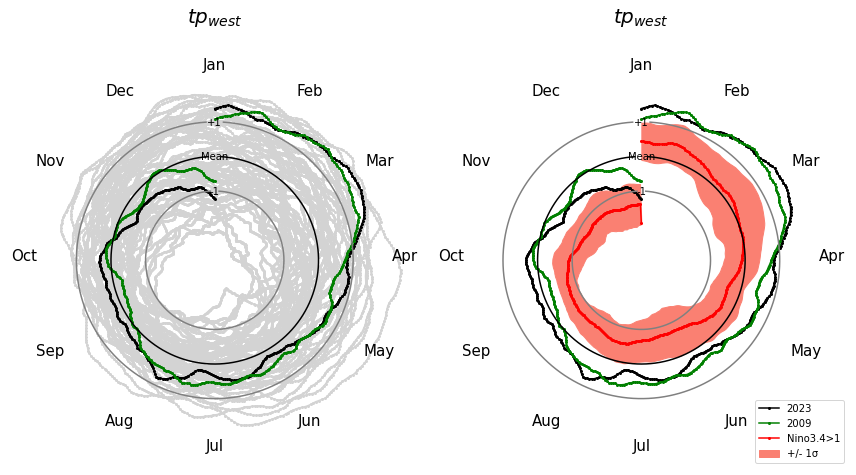

In [18]:
os = 1
# Assuming tp and ninoOND are already loaded as xarray datasets

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
full_circle_thetas = np.linspace(0, 2 * np.pi, 1000)+np.pi/2
mean_radii = np.zeros(1000)+os

# Extract years
years = np.unique(tp.time.dt.year)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 8), subplot_kw={'projection': 'polar'})
add_all = True
add_nino = True

for ax in axes:
    ax.axes.get_yaxis().set_ticklabels([])
    ax.axes.get_xaxis().set_ticklabels([])
    ax.grid(False)
    ax.set_axis_off()

    ax.set_ylim(-2,4)
    
    ax.plot(full_circle_thetas[10:990], mean_radii[10:990]+1, c='grey', zorder=10)
    ax.text(np.pi / 2, 0.90, "Mean", color="k", ha='center', zorder=10)
    #+1
    ax.plot(full_circle_thetas[10:990], mean_radii[10:990], c='k', zorder=10)
    ax.text(np.pi / 2, 1.90, "+1", color="k", ha='center', zorder=10)
    #-1
    ax.plot(full_circle_thetas[10:990], mean_radii[10:990]-1, c='grey', zorder=10)
    ax.text(np.pi / 2, -1+0.90, "-1", color="k", ha='center', zorder=10)

    months_angles = -np.linspace(0, 2 * np.pi, 13) + np.pi / 2
    for i, month in enumerate(months):
        ax.text(months_angles[i], 3.5, month, color="k", fontsize=15, ha="center")

for i, year in enumerate(years):
    temp = tp.where((tp.time.dt.year == year), drop=True).glb_anom.values
    angle = -np.linspace(0, 2 * np.pi, len(temp)) + np.pi / 2
    radius = temp + 1

    if add_all:
        axes[0].plot(angle, radius, marker='o', markersize=2, c='lightgrey')

# Plot specific years
specific_years = {'2023': 'k', '2009':'g'}
for year, color in specific_years.items():
    temp = tp.sel(time=year).glb_anom.values
    angle = -np.linspace(0, 2 * np.pi, len(temp)) + np.pi / 2
    radius = temp + 1
    for ax in axes:
        ax.plot(angle, radius, marker='o', markersize=2, label=year, color=color)

if add_nino:
    nino_tp = tp.sel(time=tp.time.dt.year.isin(ninoOND.where(ninoOND.nino34 > 1, drop=True).year[:-1]))
    temp_m = nino_tp.groupby('time.dayofyear').mean().glb_anom.values
#    temp_10 = nino_tp.glb_anom.groupby('time.dayofyear').quantile(.10)
#    temp_90 = nino_tp.glb_anom.groupby('time.dayofyear').quantile(.90)

    temp_std = nino_tp.groupby('time.dayofyear').std().glb_anom.values
    
    angle = -np.linspace(0, 2 * np.pi, len(temp_m)) + np.pi / 2
    radius_m = temp_m + 1

    axes[1].plot(angle, radius_m, marker='o', markersize=2, color='red', label = 'Nino3.4>1')
    axes[1].fill_between(angle, temp_m-temp_std + os, temp_m+temp_std + os, color='salmon', label='+/- 1σ')


    

# Set titles
axes[0].set_title(r"$tp_{west}$", color='k', fontdict={'fontsize': 20, 'fontweight':'bold'}, pad=30)
axes[1].set_title(r"$tp_{west}$", color='k', fontdict={'fontsize': 20, 'fontweight':'bold'}, pad=30)

plt.rc('text', usetex=False)
# Add legends
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()
